# Q6 LQR Lyapunov Stability
###   *by Dr. W. Vera-Tudela*

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf
import seaborn as sns

import sys
sys.path.append('../utils')   # path relative to the notebook
from Q6_functions import classify_regime, returns_volatility, frontier_optimizer, min_variance_constrained, portfolio_return, portfolio_volatility, portfolio_value, max_sharpe, neg_sharpe
from common import fetch_portfolio_data

In [2]:
# Load data
starting_capital = 10_000
period = 10
#end = pd.Timestamp.today(tz="UTC").normalize()
#start = end - pd.DateOffset(years=period)
start = '2015-01-01'
end = pd.Timestamp.today().strftime('%Y-%m-%d')

vix = yf.download('^VIX', start=start, end=end, 
                  auto_adjust=False, progress=False)['Close']


spy = yf.download('SPY', start=start, end=end,
                  auto_adjust=True, progress=False)['Close']

tickers = ['TTWO', 'DHI', 'SYY', 'EQT', 'FITB', 
           'RMD', 'AXON', 'ROP', 'NUE', 'CBRE', 'ED']

dataT, _ = fetch_portfolio_data(tickers, start, end)
assets = dataT.columns.tolist() #tickers sorted in alphabetical order, use this from now on

print(dataT.shape)
print(dataT.isna().sum())
print(dataT.index.min())

(2820, 11)
Ticker
AXON    0
CBRE    0
DHI     0
ED      0
EQT     0
FITB    0
NUE     0
RMD     0
ROP     0
SYY     0
TTWO    0
dtype: int64
2015-01-02 00:00:00


,Annualized_Return,Annualized_Volatility
Ticker,,
AXON,0.460141,0.487292
CBRE,0.188697,0.326579
DHI,0.249662,0.352554
ED,0.108278,0.207430
EQT,0.172092,0.477966
FITB,0.181405,0.354871
NUE,0.209581,0.351919
RMD,0.202029,0.310417
ROP,0.111001,0.229374


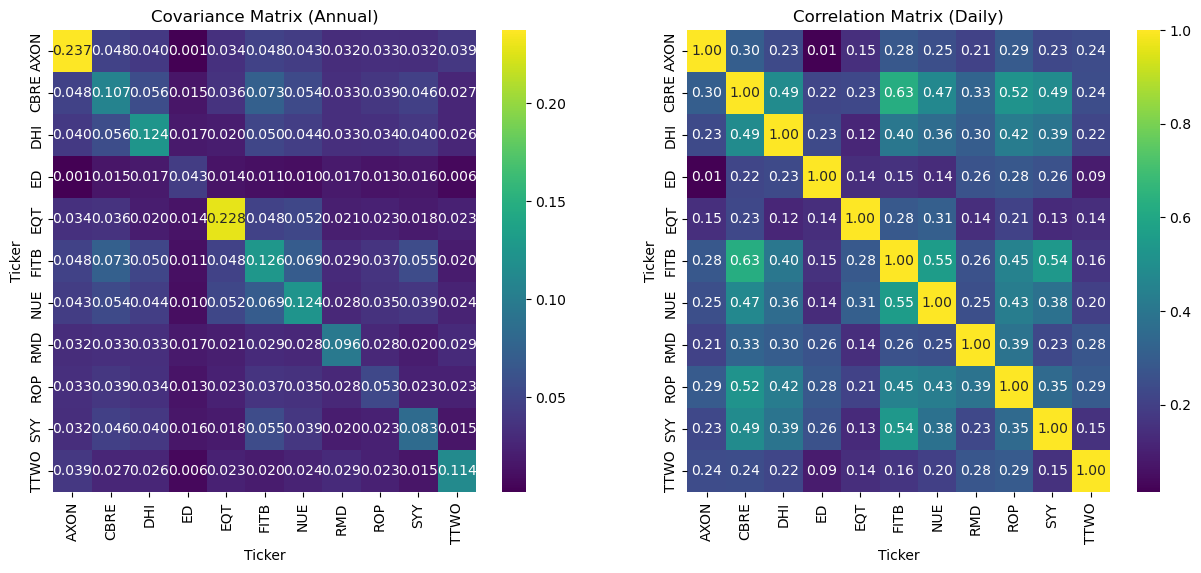

In [3]:
mu_annual, sigma_annual, cov_annual, cov_matrix, corr_matrix = returns_volatility(dataT)

In [4]:
return_min = mu_annual.min()  # lowest individual asset return
return_max = mu_annual.max()  # highest individual asset return
target_returns = np.linspace(return_min, return_max, 100)
frontier_volatilities, frontier_returns, frontier_weights = frontier_optimizer(mu_annual, sigma_annual, cov_annual, target_returns)

In [5]:
n_simulations = 10_000
sim_returns, sim_vols, sim_sharpes = [], [], []

for _ in range(n_simulations):
    w = np.random.dirichlet(np.ones(len(assets)))
    r = portfolio_return(w, mu_annual)
    v = portfolio_volatility(w, cov_annual)
    s = (r - 0.04) / v
    sim_returns.append(r)
    sim_vols.append(v)
    sim_sharpes.append(s)

In [6]:
# Equal-weight portfolio

w_equal = np.ones(len(assets)) / len(assets)

# Equal weight portfolio stats
w_equal = np.ones(len(assets)) / len(assets)
ret_equal = portfolio_return(w_equal, mu_annual)
vol_equal = portfolio_volatility(w_equal, cov_annual)
sharpe_equal = (ret_equal - 0.04) / vol_equal

# display(pd.Series(w_equal, index=assets).round(4))

port_value_eq = portfolio_value(starting_capital, dataT, w_equal)

In [7]:
# Optimizing the portfolio weight to obtain the same returns as the equally distributed weights but minimizing the volatility

# Now find the frontier portfolio at the same return
result = min_variance_constrained(ret_equal, mu_annual, cov_annual)
w_optimized = result.x
vol_optimized = portfolio_volatility(w_optimized, cov_annual)

print(f"Equal weight: ret={ret_equal:.3f}, vol={vol_equal:.3f}, sharpe={sharpe_equal:.3f}")
print(f"Optimized:    ret={ret_equal:.3f}, vol={vol_optimized:.3f}")
print(f"Volatility reduction: {(vol_optimized/vol_equal - 1)*100:.1f}%")

# display(pd.Series(w_optimized, index=assets).round(4))

port_value_op = portfolio_value(starting_capital, dataT, w_optimized)

weights_table = pd.DataFrame({
    'Asset': assets,
    'Weight (%)': (w_optimized*100).round(1)
}).set_index('Asset')

display(weights_table)

Equal weight: ret=0.208, vol=0.199, sharpe=0.841
Optimized:    ret=0.208, vol=0.177
Volatility reduction: -11.4%


,Weight (%)
Asset,
AXON,11.7
CBRE,0.0
DHI,7.1
ED,25.0
EQT,3.8
FITB,0.0
NUE,5.3
RMD,10.9
ROP,9.0


In [8]:
# calculating the case with the minimum volatility from the efficient frontier
idx = np.argmin(frontier_volatilities)
min_vol = frontier_volatilities[idx]
min_ret = frontier_returns[idx]
min_w = frontier_weights[idx]

print(f"Returns: {min_ret:.4f}")
print(f"Min. Volatility: {min_vol:.4f}")

port_value_mi = portfolio_value(starting_capital, dataT, min_w)

Returns: 0.1474
Min. Volatility: 0.1602


In [9]:
# calculating the weights for maximum Sharpe value
sharpe_result = max_sharpe(mu_annual, cov_annual)
sharpe_weights = sharpe_result.x
sharpe_ret = portfolio_return(sharpe_weights, mu_annual)
sharpe_vol = portfolio_volatility(sharpe_weights, cov_annual)

print(f"Sharpe Returns: {sharpe_ret:.4f}")
print(f"Sharpe Volatility: {sharpe_vol:.4f}")
print(f"Sharpe Ratio: {-sharpe_result.fun:.4f}")

port_value_sh = portfolio_value(starting_capital, dataT, sharpe_weights)

Sharpe Returns: 0.2792
Sharpe Volatility: 0.2243
Sharpe Ratio: 1.0663


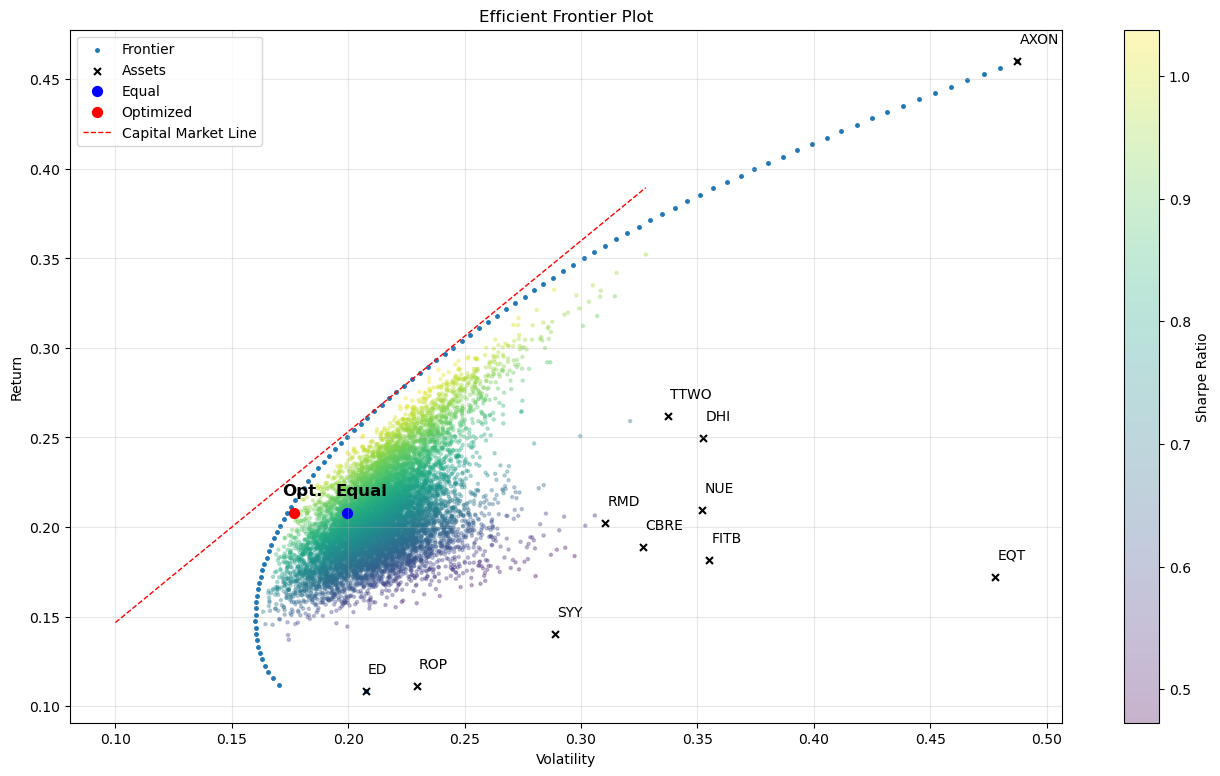

In [10]:
plt.figure(figsize=(16, 9))
colors = sns.color_palette("colorblind")

plt.scatter(frontier_volatilities, frontier_returns, s=25, marker='.', label='Frontier')

plt.scatter(sim_vols, sim_returns, c=sim_sharpes, cmap='viridis', alpha=0.3, s=5)
plt.colorbar(label='Sharpe Ratio')

plt.scatter(sigma_annual, mu_annual, s=25, c='k', marker='x', label='Assets')
for asset in assets:
    plt.annotate(asset, (sigma_annual[asset]+0.001, mu_annual[asset]+0.01),fontsize=10)

plt.scatter(vol_equal, ret_equal, s=50, c='b', marker='o', label='Equal')
plt.annotate('Equal', (vol_equal-0.005, ret_equal+0.01),fontweight='bold',fontsize=12)

plt.scatter(vol_optimized, ret_equal, s=50, c='r', marker='o', label='Optimized')
plt.annotate('Opt.', (vol_optimized-0.005, ret_equal+0.01),fontweight='bold',fontsize=12)

# CML: from (0, rf) through (sharpe_vol, sharpe_ret)
cml_x = np.linspace(0.1, max(sim_vols), 100)
cml_y = 0.04 + (sharpe_ret - 0.04) / sharpe_vol * cml_x
plt.plot(cml_x, cml_y, 'r--', linewidth=1, label='Capital Market Line')

plt.grid(True, alpha=0.3)
plt.xlabel('Volatility')
plt.ylabel('Return')
plt.legend()

plt.title('Efficient Frontier Plot')
plt.show()

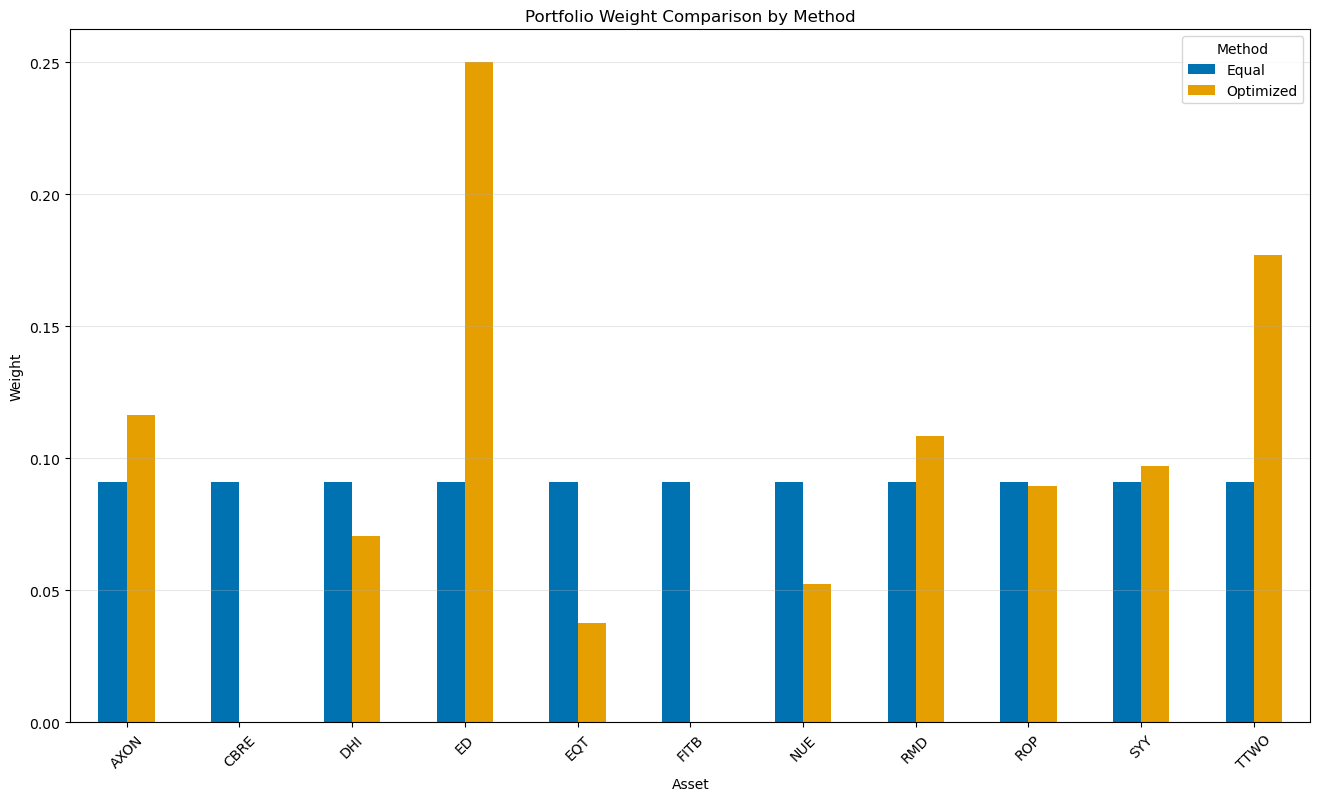

In [11]:
weights_df = pd.DataFrame({
    "Equal": w_equal,
    "Optimized": w_optimized,
    },
    index=assets
)

colors = [
    "#0072B2", "#E69F00", "#009E73", "#D55E00",
    "#CC79A7", "#F0E442", "#56B4E9", "#000000"
]

weights_df.plot(kind="bar", figsize=(16, 9), color=colors[:len(weights_df.columns)])

plt.title("Portfolio Weight Comparison by Method")
plt.ylabel("Weight")
plt.xlabel("Asset")
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)
plt.legend(title="Method")

plt.show()

# Regime detection using three signals
spy_ret_252 = SPY 252-day return        # trend  
vix_level   = VIX or realized vol       # stress  
ma_signal   = SPY MA50 > MA200          # momentum  

Bull:   spy_ret > 15%, vol < 15%, ma = golden cross  
Neutral: moderate returns, moderate vol  
Bear:   spy_ret < 0%, vol > 20%, ma = death cross 
Crisis: spy_ret < -20%, vol > 35%, ma = death cross  

# Regime classification
VIX < 15        → Bull (complacency)  
15 ≤ VIX < 20   → Neutral (normal)  
20 ≤ VIX < 30   → Bear (elevated concern)  
VIX ≥ 30        → Crisis (fear/panic)

In [12]:
spy_ma50  = spy.rolling(50).mean()
spy_ma200 = spy.rolling(200).mean()
spy_trend = (spy_ma50 > spy_ma200).astype(int)  # 1=bull, 0=bear

In [13]:
vix_series = vix.squeeze()  # ensure it's a 1D Series
spy_trend_series = spy_trend.squeeze()

# Align both to common dates
common_idx = vix_series.index.intersection(spy_trend_series.index)
vix_aligned = vix_series.loc[common_idx]
spy_aligned = spy_trend_series.loc[common_idx]

mask = vix_aligned.notna() & spy_aligned.notna()
vix_aligned = vix_aligned[mask]
spy_aligned = spy_aligned[mask]

regime = pd.Series([
    classify_regime(float(v), int(t))
    for v, t in zip(vix_aligned.values, spy_aligned.values)
], index=common_idx)

print(regime.value_counts(normalize=True))

Bear       0.395035
Bull       0.315248
Neutral    0.265603
Crisis     0.024113
Name: proportion, dtype: float64


In [14]:
w_star = w_optimized  # target equilibrium

In [15]:
assets = data.columns.tolist()
w_star = pd.Series(w_optimized, index=assets)
'''

**Now the LQR engine — conceptual design first.**

The discrete-time LQR problem for portfolio rebalancing:
'''
State:    x(k) = w(k) - w*        # weight deviation
Dynamics: x(k+1) = A x(k) + B u(k)
Cost:     J = Σ [x^T Q x + u^T R u]
Control:  u*(k) = -K x(k)          # optimal rebalancing trades

SyntaxError: invalid syntax (116509096.py, line 9)

In [ ]:
# A matrix — identity (weights persist without rebalancing)
A = np.eye(n)

# B matrix — rebalancing trades directly change weights
B = np.eye(n)

# Q matrix — penalty for deviation from target
Q = np.diag([qi for each asset])  # larger = tighter tracking

# R matrix — penalty for trading (transaction costs)
R = np.diag([ri for each asset])  # larger = less frequent rebalancing

In [ ]:
from scipy.linalg import solve_discrete_are

P = solve_discrete_are(A, B, Q, R)
K = np.linalg.inv(R + B.T @ P @ B) @ B.T @ P @ A

In [ ]:
regime_params = {
    'Bull':    {'q': ?, 'r': ?},
    'Neutral': {'q': ?, 'r': ?},
    'Bear':    {'q': ?, 'r': ?},
    'Crisis':  {'q': ?, 'r': ?}
}